Introductie

In deze notebook voeren we een verkennende analyse uit op een dataset met gezondheidsvariabelen.
Het doel is om inzicht te krijgen in de structuur van de data, relaties tussen variabelen te ontdekken en de dataset voor te bereiden op machine learning.

De analyse bestaat uit:

Verkennen van de dataset

Analyse van individuele variabelen

Analyse van relaties tussen variabelen

Normalisatie en voorbereiding voor machine learning

1. Imports

We beginnen met het importeren van de benodigde libraries voor data-analyse, visualisatie en statistiek.

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8")

2. Dataset inladen

We laden de dataset in en bekijken de eerste rijen om een eerste indruk van de data te krijgen.

In [6]:
df = pd.read_csv("cardiovascular_risk_dataset.csv")

df.head()

,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,1,62,25.0,142,93,247,72,Never,11565,3,5.6,8.2,No,7,0.7,28.1,Medium
1,2,54,29.7,158,101,254,74,Current,4036,8,0.5,6.7,No,5,4.5,63.0,High
2,3,46,36.2,170,113,276,80,Current,3043,9,0.4,4.0,No,1,20.8,73.1,High
3,4,48,30.4,153,98,230,73,Former,5604,5,0.6,8.0,No,4,8.5,39.5,Medium
4,5,46,25.3,139,87,206,69,Current,7464,1,2.0,6.1,No,5,3.6,29.3,Medium


We controleren ook het aantal rijen en kolommen.

In [7]:
df.shape

(5500, 17)

Dit geeft inzicht in de grootte van de dataset.

3. Structuur van de dataset

We bekijken de structuur van de dataset en controleren de datatypes van de variabelen.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Patient_ID                        5500 non-null   int64  
 1   age                               5500 non-null   int64  
 2   bmi                               5500 non-null   float64
 3   systolic_bp                       5500 non-null   int64  
 4   diastolic_bp                      5500 non-null   int64  
 5   cholesterol_mg_dl                 5500 non-null   int64  
 6   resting_heart_rate                5500 non-null   int64  
 7   smoking_status                    5500 non-null   object 
 8   daily_steps                       5500 non-null   int64  
 9   stress_level                      5500 non-null   int64  
 10  physical_activity_hours_per_week  5500 non-null   float64
 11  sleep_hours                       5500 non-null   float64
 12  family

Daarnaast bekijken we statistische samenvattingen van de numerieke variabelen.

In [9]:
df.describe()

,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score
count,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000
mean,2750.500000,53.872000,28.170818,147.248182,95.756727,239.684182,74.075091,5902.929455,4.907091,3.299364,6.869364,5.162909,3.782200,37.540455
std,1587.857571,21.196017,4.189877,13.222701,9.451559,28.570177,6.392166,3041.084590,2.298173,2.672457,1.091263,2.286134,3.515594,24.287026
min,1.000000,18.000000,15.000000,108.000000,64.000000,147.000000,48.000000,500.000000,1.000000,0.000000,4.000000,1.000000,0.000000,0.000000
25%,1375.750000,36.000000,25.200000,138.000000,89.000000,220.000000,70.000000,3428.000000,3.000000,1.200000,6.200000,3.000000,1.200000,18.400000
50%,2750.500000,54.000000,28.400000,147.000000,96.000000,240.000000,74.000000,5460.000000,5.000000,2.600000,6.900000,5.000000,2.800000,36.700000
75%,4125.250000,72.000000,31.100000,156.000000,102.000000,260.000000,79.000000,7772.000000,7.000000,4.900000,7.600000,7.000000,5.300000,55.500000
max,5500.000000,90.000000,40.900000,192.000000,120.000000,331.000000,92.000000,16793.000000,10.000000,12.900000,10.000000,10.000000,29.200000,100.000000


Hieruit kunnen we bijvoorbeeld aflezen:

gemiddelde leeftijd

spreiding van BMI

gemiddelde cholesterolwaarden

4. Missende waarden

Het is belangrijk om te controleren of de dataset missende waarden bevat.

In [10]:
df.isnull().sum()

Patient_ID                          0
age                                 0
bmi                                 0
systolic_bp                         0
diastolic_bp                        0
cholesterol_mg_dl                   0
resting_heart_rate                  0
smoking_status                      0
daily_steps                         0
stress_level                        0
physical_activity_hours_per_week    0
sleep_hours                         0
family_history_heart_disease        0
diet_quality_score                  0
alcohol_units_per_week              0
heart_disease_risk_score            0
risk_category                       0
dtype: int64

Missende waarden kunnen later worden behandeld door:

verwijderen van rijen

imputatie met gemiddelde of mediaan

5. Data dictionary

We maken een overzicht van alle variabelen en hun datatypes.

In [11]:
data_dictionary = pd.DataFrame({
    "Variabele": df.columns,
    "Datatype": df.dtypes
})

data_dictionary

,Variabele,Datatype
Patient_ID,Patient_ID,int64
age,age,int64
bmi,bmi,float64
systolic_bp,systolic_bp,int64
diastolic_bp,diastolic_bp,int64
cholesterol_mg_dl,cholesterol_mg_dl,int64
resting_heart_rate,resting_heart_rate,int64
smoking_status,smoking_status,object
daily_steps,daily_steps,int64
stress_level,stress_level,int64


Hiermee kunnen we onderscheid maken tussen:

Numerieke variabelen

Categorische variabelen

Deel 1 – Analyse van afzonderlijke variabelen

6. 
Numerieke variabelen

We selecteren alle numerieke kolommen in de dataset.

In [12]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

numerical_cols

Index(['Patient_ID', 'age', 'bmi', 'systolic_bp', 'diastolic_bp',
       'cholesterol_mg_dl', 'resting_heart_rate', 'daily_steps',
       'stress_level', 'physical_activity_hours_per_week', 'sleep_hours',
       'diet_quality_score', 'alcohol_units_per_week',
       'heart_disease_risk_score'],
      dtype='object')

We bekijken de verdeling van elke numerieke variabele.

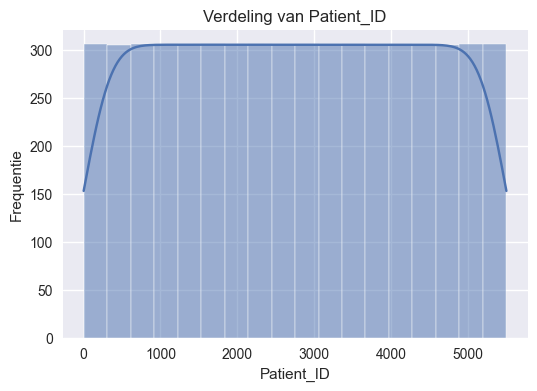

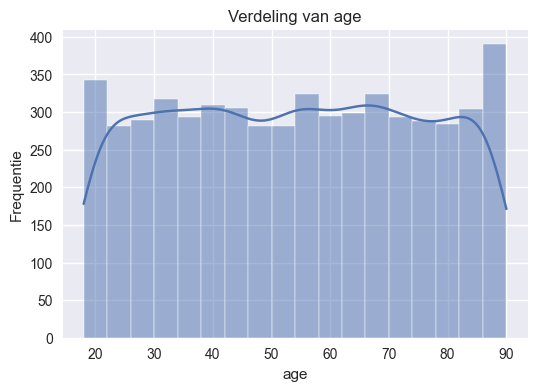

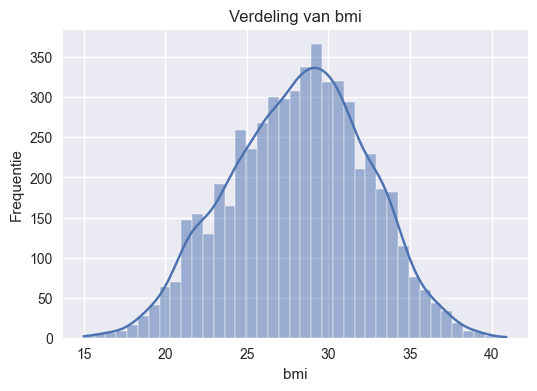

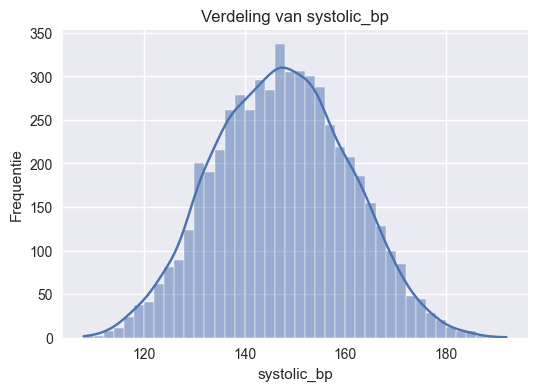

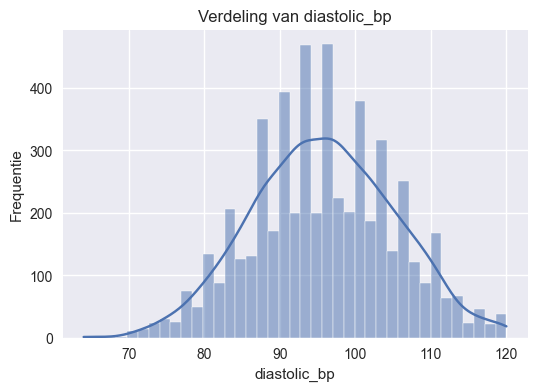

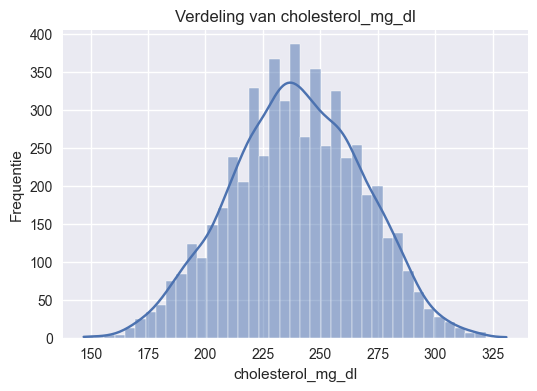

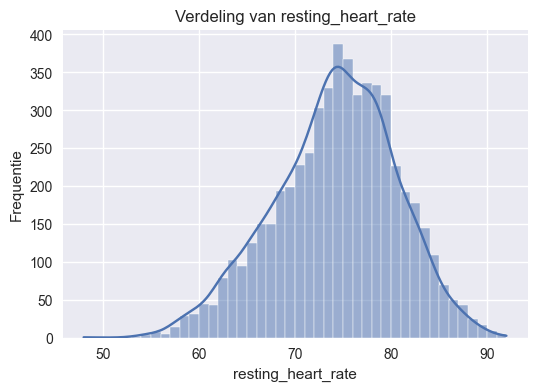

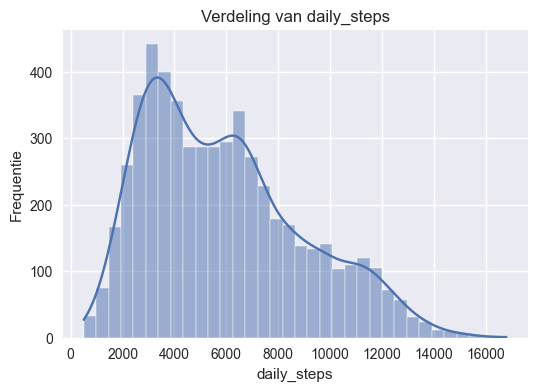

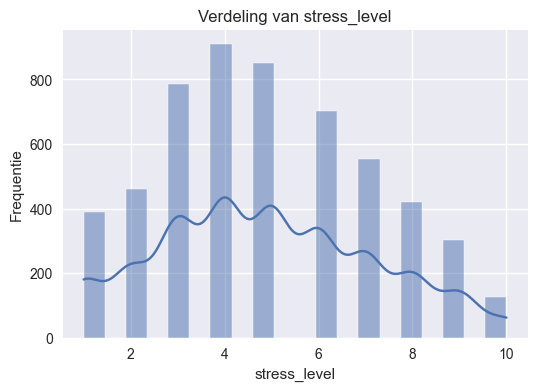

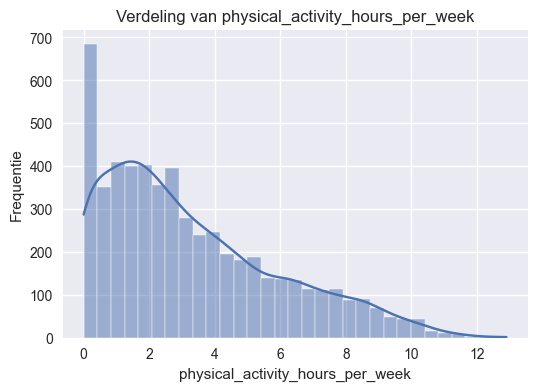

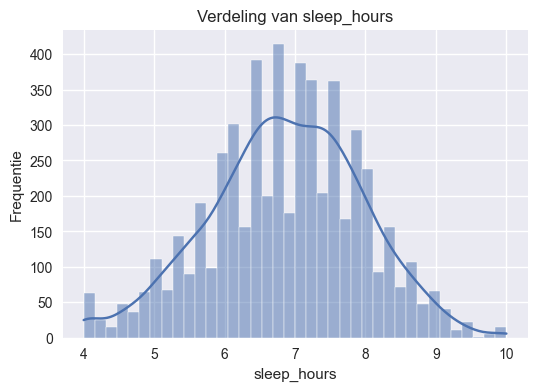

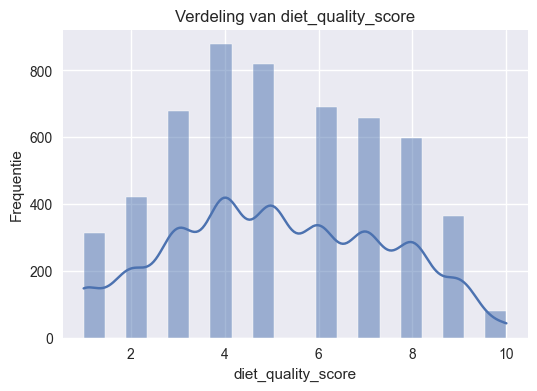

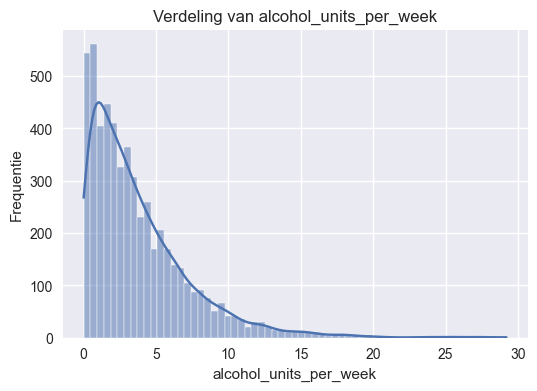

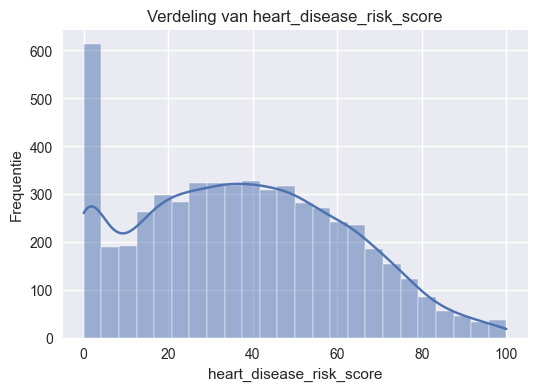

In [13]:
for col in numerical_cols:
    
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    
    plt.title(f"Verdeling van {col}")
    plt.xlabel(col)
    plt.ylabel("Frequentie")
    
    plt.show()

Deze grafieken geven inzicht in:

scheve verdelingen

mogelijke outliers

normale verdelingen


7. Normaliteit testen

We testen of variabelen normaal verdeeld zijn met de Shapiro-Wilk test.

Omdat de dataset groot is, gebruiken we een steekproef.

In [14]:
for col in numerical_cols:
    
    sample = df[col].dropna().sample(min(500, len(df)))
    
    stat, p = stats.shapiro(sample)
    
    print(col)
    print("p-value:", p)
    print()

Patient_ID
p-value: 7.718566396352067e-12

age
p-value: 1.0156883955243727e-12

bmi
p-value: 0.10868475063943628

systolic_bp
p-value: 0.20103032118942632

diastolic_bp
p-value: 0.09258701909289212

cholesterol_mg_dl
p-value: 0.05047625636845389

resting_heart_rate
p-value: 0.014406639161307475

daily_steps
p-value: 2.679154443734977e-10

stress_level
p-value: 9.695960792516745e-12

physical_activity_hours_per_week
p-value: 1.216923897164473e-14

sleep_hours
p-value: 0.1273063542708665

diet_quality_score
p-value: 5.926079832262808e-10

alcohol_units_per_week
p-value: 6.513383365504645e-22

heart_disease_risk_score
p-value: 1.7249553584745787e-09



Interpretatie:
p < 0.05 → variabele is waarschijnlijk niet normaal verdeeld

8. Categorische variabelen

We analyseren de categorische variabelen.

In [15]:
categorical_cols = df.select_dtypes(include=["object"]).columns

categorical_cols

Index(['smoking_status', 'family_history_heart_disease', 'risk_category'], dtype='object')

We bekijken de frequentie van elke categorie.

In [16]:
for col in categorical_cols:
    
    print("Frequenties van", col)
    print(df[col].value_counts())
    print()

Frequenties van smoking_status
smoking_status
Never      3627
Current     994
Former      879
Name: count, dtype: int64

Frequenties van family_history_heart_disease
family_history_heart_disease
No     4134
Yes    1366
Name: count, dtype: int64

Frequenties van risk_category
risk_category
Medium    2244
Low       1838
High      1418
Name: count, dtype: int64



Visualisatie van de categorieën:

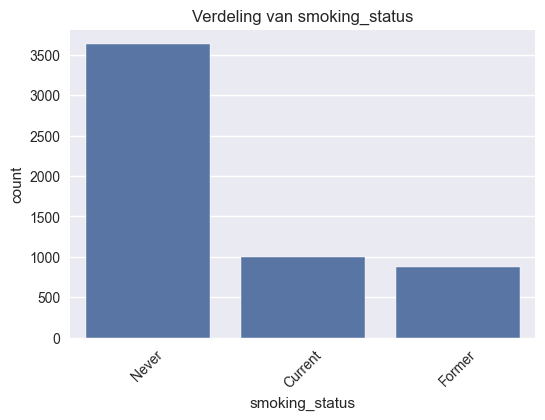

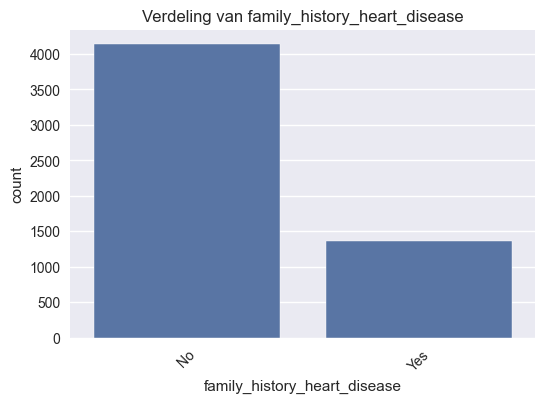

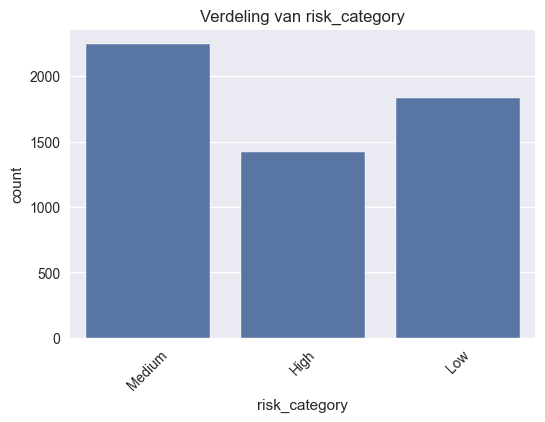

In [17]:
for col in categorical_cols:
    
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    
    plt.title(f"Verdeling van {col}")
    
    plt.xticks(rotation=45)
    
    plt.show()

Deel 2 – Relaties tussen variabelen
9. Correlatie tussen numerieke variabelen

We berekenen de Pearson correlatie tussen alle numerieke variabelen.

In [18]:
corr_matrix = df[numerical_cols].corr()

corr_matrix

,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score
Patient_ID,1.000000,-0.028401,-0.001991,-0.023890,-0.024548,-0.015367,0.025366,-0.014108,0.001242,-0.018473,0.009512,-0.002965,0.014921,-0.021508
age,-0.028401,1.000000,0.246300,0.718108,0.647239,0.661048,0.001981,-0.008763,-0.000405,-0.004214,-0.002322,0.009501,-0.005852,0.694286
bmi,-0.001991,0.246300,1.000000,0.615659,0.554239,0.768706,0.509978,-0.622660,0.313794,-0.676245,-0.079921,-0.817546,0.311838,0.713077
systolic_bp,-0.023890,0.718108,0.615659,1.000000,0.905337,0.766537,0.369686,-0.384431,0.421383,-0.400191,-0.111325,-0.398081,0.290831,0.901038
diastolic_bp,-0.024548,0.647239,0.554239,0.905337,1.000000,0.692246,0.342111,-0.339437,0.389865,-0.356744,-0.110172,-0.356313,0.254808,0.813140
cholesterol_mg_dl,-0.015367,0.661048,0.768706,0.766537,0.692246,1.000000,0.345943,-0.447553,0.230487,-0.456274,-0.059209,-0.636478,0.217506,0.852483
resting_heart_rate,0.025366,0.001981,0.509978,0.369686,0.342111,0.345943,1.000000,-0.562579,0.534913,-0.732027,-0.131529,-0.483224,0.347258,0.428760
daily_steps,-0.014108,-0.008763,-0.622660,-0.384431,-0.339437,-0.447553,-0.562579,1.000000,-0.404731,0.730745,0.136136,0.660004,-0.408799,-0.478631
stress_level,0.001242,-0.000405,0.313794,0.421383,0.389865,0.230487,0.534913,-0.404731,1.000000,-0.395330,-0.226630,-0.329363,0.374151,0.377445
physical_activity_hours_per_week,-0.018473,-0.004214,-0.676245,-0.400191,-0.356744,-0.456274,-0.732027,0.730745,-0.395330,1.000000,0.106789,0.639595,-0.398362,-0.520258


We visualiseren de correlatiematrix.

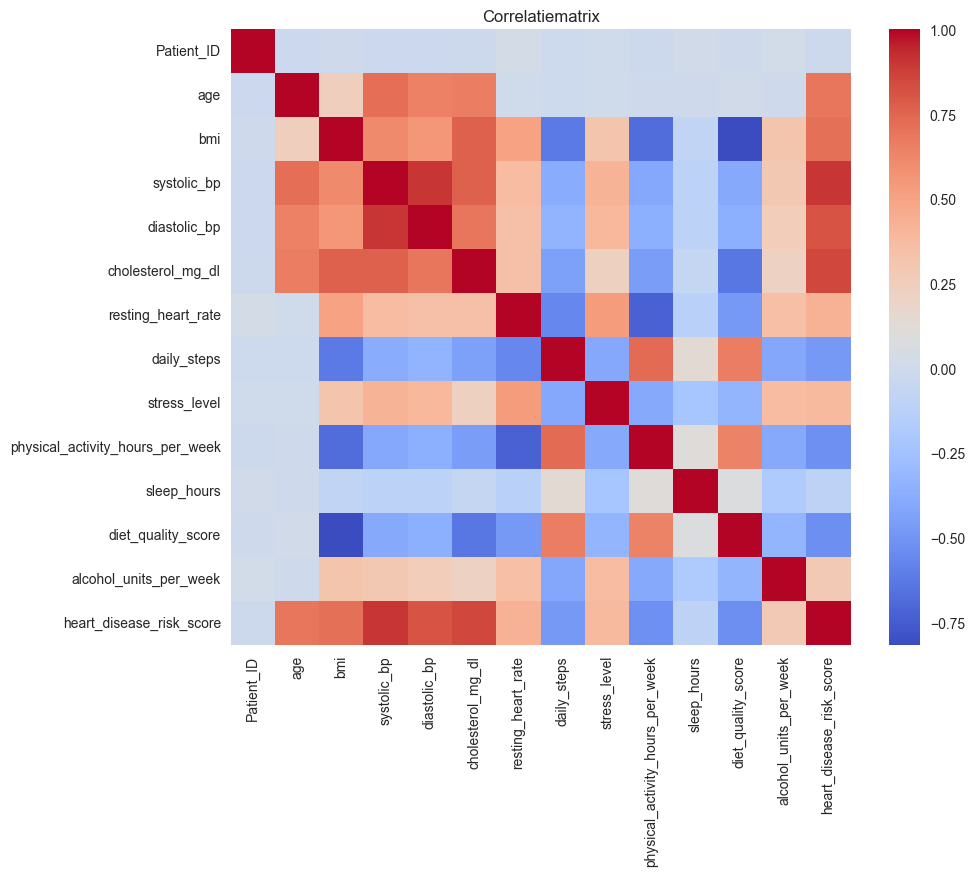

In [19]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlatiematrix")

plt.show()

Sterke correlaties kunnen wijzen op afhankelijkheden tussen variabelen.

10. Correlatie met risicoscore

We berekenen de Pearson correlatie tussen elke feature en de heart disease risk score.

In [20]:
target = "heart_disease_risk_score"

for col in numerical_cols:
    
    if col != target:
        
        r, p = stats.pearsonr(df[col], df[target])
        
        print(col)
        print("correlatie:", r)
        print("p-value:", p)
        print()

Patient_ID
correlatie: -0.021508039539773587
p-value: 0.11073441548382235

age
correlatie: 0.6942860722556752
p-value: 0.0

bmi
correlatie: 0.7130767808536306
p-value: 0.0

systolic_bp
correlatie: 0.9010378096117337
p-value: 0.0

diastolic_bp
correlatie: 0.8131397733456012
p-value: 0.0

cholesterol_mg_dl
correlatie: 0.8524830791916579
p-value: 0.0

resting_heart_rate
correlatie: 0.4287596041145608
p-value: 7.536682041286157e-245

daily_steps
correlatie: -0.47863118077183
p-value: 5.34640369797e-313

stress_level
correlatie: 0.3774452392486679
p-value: 9.203767731563209e-186

physical_activity_hours_per_week
correlatie: -0.520258243235122
p-value: 0.0

sleep_hours
correlatie: -0.10537861092900506
p-value: 4.683451328544075e-15

diet_quality_score
correlatie: -0.5308382525387512
p-value: 0.0

alcohol_units_per_week
correlatie: 0.28913034816112465
p-value: 2.2207195762128076e-106



11. Phi coefficient (categorische variabelen)

Voor categorische variabelen gebruiken we de Phi coefficient.

In [21]:
df["high_risk"] = (df["risk_category"] == "High").astype(int)

cont_table = pd.crosstab(
    df["family_history_heart_disease"],
    df["high_risk"]
)

chi2 = stats.chi2_contingency(cont_table)[0]

n = cont_table.sum().sum()

phi = np.sqrt(chi2 / n)

phi

np.float64(0.11959685514583214)

Phi waarden:
0 → geen relatie
1 → sterke relatie

12. Jaccard index

Voor binaire variabelen kunnen we de Jaccard index gebruiken.

In [22]:
df["current_smoker"] = (df["smoking_status"] == "Current").astype(int)

intersection = np.logical_and(
    df["current_smoker"],
    df["high_risk"]
).sum()

union = np.logical_or(
    df["current_smoker"],
    df["high_risk"]
).sum()

jaccard = intersection / union

jaccard

np.float64(0.3037837837837838)

Normalisatie
13. Z-score normalisatie

Voor veel machine learning modellen moeten features worden genormaliseerd.

In [23]:
from scipy.stats import zscore

df_z = df.copy()

for col in numerical_cols:
    
    df_z[col + "_z"] = zscore(df[col])
    
df_z.head()

,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category,high_risk,current_smoker,Patient_ID_z,age_z,bmi_z,systolic_bp_z,diastolic_bp_z,cholesterol_mg_dl_z,resting_heart_rate_z,daily_steps_z,stress_level_z,physical_activity_hours_per_week_z,sleep_hours_z,diet_quality_score_z,alcohol_units_per_week_z,heart_disease_risk_score_z
0,1,62,25.0,142,93,247,72,Never,11565,3,5.6,8.2,No,7,0.7,28.1,Medium,0,0,-1.731736,0.383503,-0.756850,-0.396943,-0.291696,0.256088,-0.324660,1.862028,-0.829904,0.860948,1.219466,0.803653,-0.876802,-0.388739
1,2,54,29.7,158,101,254,74,Current,4036,8,0.5,6.7,No,5,4.5,63.0,High,1,1,-1.731106,0.006039,0.365004,0.813207,0.554803,0.501121,-0.011748,-0.613958,1.345934,-1.047582,-0.155214,-0.071266,0.204195,1.048373
2,3,46,36.2,170,113,276,80,Current,3043,9,0.4,4.0,No,1,20.8,73.1,High,1,1,-1.730476,-0.371424,1.916503,1.720820,1.824550,1.271225,0.926986,-0.940516,1.781102,-1.085004,-2.629637,-1.821104,4.841101,1.464271
3,4,48,30.4,153,98,230,73,Former,5604,5,0.6,8.0,No,4,8.5,39.5,Medium,0,0,-1.729846,-0.277058,0.532088,0.435035,0.237366,-0.338992,-0.168204,-0.098306,0.040431,-1.010160,1.036175,-0.508725,1.342086,0.080690
4,5,46,25.3,139,87,206,69,Current,7464,1,2.0,6.1,No,5,3.6,29.3,Medium,0,1,-1.729217,-0.371424,-0.685242,-0.623846,-0.926569,-1.179105,-0.794027,0.513374,-1.700240,-0.486250,-0.705086,-0.071266,-0.051831,-0.339325


14. Percentielscore

We berekenen een percentielscore voor de risicoscore.

In [24]:
df["risk_percentile"] = df["heart_disease_risk_score"].rank(pct=True)

df[["heart_disease_risk_score", "risk_percentile"]].head()

,heart_disease_risk_score,risk_percentile
0,28.1,0.379636
1,63.0,0.831000
2,73.1,0.919818
3,39.5,0.536818
4,29.3,0.394818


Voorbereiding voor Machine Learning
15. Irrelevante variabelen verwijderen

ID-velden bevatten geen bruikbare informatie voor machine learning.

In [25]:
df_ml = df.drop(columns=["Patient_ID"])

16. One-hot encoding

Categorische variabelen moeten worden omgezet naar numerieke waarden.

In [26]:
df_encoded = pd.get_dummies(df_ml, drop_first=True)

df_encoded.head()

,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,high_risk,current_smoker,risk_percentile,smoking_status_Former,smoking_status_Never,family_history_heart_disease_Yes,risk_category_Low,risk_category_Medium
0,62,25.0,142,93,247,72,11565,3,5.6,8.2,7,0.7,28.1,0,0,0.379636,False,True,False,False,True
1,54,29.7,158,101,254,74,4036,8,0.5,6.7,5,4.5,63.0,1,1,0.831000,False,False,False,False,False
2,46,36.2,170,113,276,80,3043,9,0.4,4.0,1,20.8,73.1,1,1,0.919818,False,False,False,False,False
3,48,30.4,153,98,230,73,5604,5,0.6,8.0,4,8.5,39.5,0,0,0.536818,True,False,False,False,True
4,46,25.3,139,87,206,69,7464,1,2.0,6.1,5,3.6,29.3,0,1,0.394818,False,False,False,False,True


17. Feature scaling

We schalen de data zodat alle features vergelijkbare schalen hebben.

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_encoded)

df_scaled = pd.DataFrame(
    scaled_data,
    columns=df_encoded.columns
)

df_scaled.head()

,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,high_risk,current_smoker,risk_percentile,smoking_status_Former,smoking_status_Never,family_history_heart_disease_Yes,risk_category_Low,risk_category_Medium
0,0.383503,-0.756850,-0.396943,-0.291696,0.256088,-0.324660,1.862028,-0.829904,0.860948,1.219466,0.803653,-0.876802,-0.388739,-0.589388,-0.469675,-0.417408,-0.436141,0.718613,-0.574831,-0.708457,1.204566
1,0.006039,0.365004,0.813207,0.554803,0.501121,-0.011748,-0.613958,1.345934,-1.047582,-0.155214,-0.071266,0.204195,1.048373,1.696674,2.129131,1.146690,-0.436141,-1.391569,-0.574831,-0.708457,-0.830174
2,-0.371424,1.916503,1.720820,1.824550,1.271225,0.926986,-0.940516,1.781102,-1.085004,-2.629637,-1.821104,4.841101,1.464271,1.696674,2.129131,1.454469,-0.436141,-1.391569,-0.574831,-0.708457,-0.830174
3,-0.277058,0.532088,0.435035,0.237366,-0.338992,-0.168204,-0.098306,0.040431,-1.010160,1.036175,-0.508725,1.342086,0.080690,-0.589388,-0.469675,0.127270,2.292839,-1.391569,-0.574831,-0.708457,1.204566
4,-0.371424,-0.685242,-0.623846,-0.926569,-1.179105,-0.794027,0.513374,-1.700240,-0.486250,-0.705086,-0.071266,-0.051831,-0.339325,-0.589388,2.129131,-0.364799,-0.436141,-1.391569,-0.574831,-0.708457,1.204566


Conclusie
Uit de analyse blijkt dat:
De dataset zowel numerieke als categorische variabelen bevat
Sommige features correleren met het hartziekterisico
Categorische variabelen moeten worden geëncodeerd
Normalisatie is nodig voor veel machine learning modellen
De dataset is nu voorbereid voor verdere analyse en modelontwikkeling.